In [11]:
import pandas as pd
from ift6758.data import SeasonData
from ift6758.data.data_cleaning import clean_season_data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
############################## Question 4 #1 ##############################

In [12]:
## First, we get the data from season 2022-2023, clean it and save it to a dataframe
season2022Data = SeasonData(2022)
season2022Data.get_data_from_api()
df = clean_season_data(season2022Data)

df.head(10)

,game_id,period,period_time,team,event_type,x_coord,y_coord,standardized_x_coord,standardized_y_coord,shooter,goalie,shot_type,empty_net,strength,season,game_type
0,2022020001,1,00:23,28,Shot,44.0,8.0,44.0,8.0,Player_8478414,Goalie_8477424,wrist,False,Even,2022,Regular
1,2022020001,1,00:59,18,Shot,-33.0,8.0,33.0,-8.0,Player_8475218,Goalie_8473503,slap,False,Even,2022,Regular
2,2022020001,1,01:01,18,Goal,-74.0,-5.0,74.0,5.0,Player_8480748,Goalie_8473503,wrist,False,Even,2022,Regular
3,2022020001,1,01:12,18,Shot,-81.0,15.0,81.0,-15.0,Player_8476925,Goalie_8473503,wrist,False,Even,2022,Regular
4,2022020001,1,02:42,28,Shot,72.0,2.0,72.0,2.0,Player_8478904,Goalie_8477424,tip-in,False,Even,2022,Regular
5,2022020001,1,04:09,18,Shot,-40.0,22.0,40.0,-22.0,Player_8479371,Goalie_8473503,snap,False,Even,2022,Regular
6,2022020001,1,04:19,28,Shot,49.0,12.0,49.0,12.0,Player_8478067,Goalie_8477424,wrist,False,Even,2022,Regular
7,2022020001,1,04:44,28,Shot,46.0,18.0,46.0,18.0,Player_8478099,Goalie_8477424,slap,False,Even,2022,Regular
8,2022020001,1,05:45,18,Shot,-40.0,13.0,40.0,-13.0,Player_8475168,Goalie_8473503,wrist,False,Even,2022,Regular
9,2022020001,1,06:23,18,Shot,-71.0,21.0,71.0,-21.0,Player_8480009,Goalie_8473503,wrist,False,Even,2022,Regular


In [8]:
total_shots_df = df.groupby("shot_type")["event_type"].count()
goals_df = df[df["event_type"] == "Goal"].groupby("shot_type")["event_type"].count()

shots_df = pd.DataFrame({"total_shots": total_shots_df, "goals": goals_df}).fillna(0)

print(shots_df)

              total_shots  goals
shot_type                       
Unknown                22     22
backhand             7014    785
bat                   211     54
between-legs           52      8
cradle                  2      1
deflected            1394    236
poke                  422     65
slap                10054    755
snap                14213   1681
tip-in               5726    908
wrap-around           778     61
wrist               48198   4451


[]

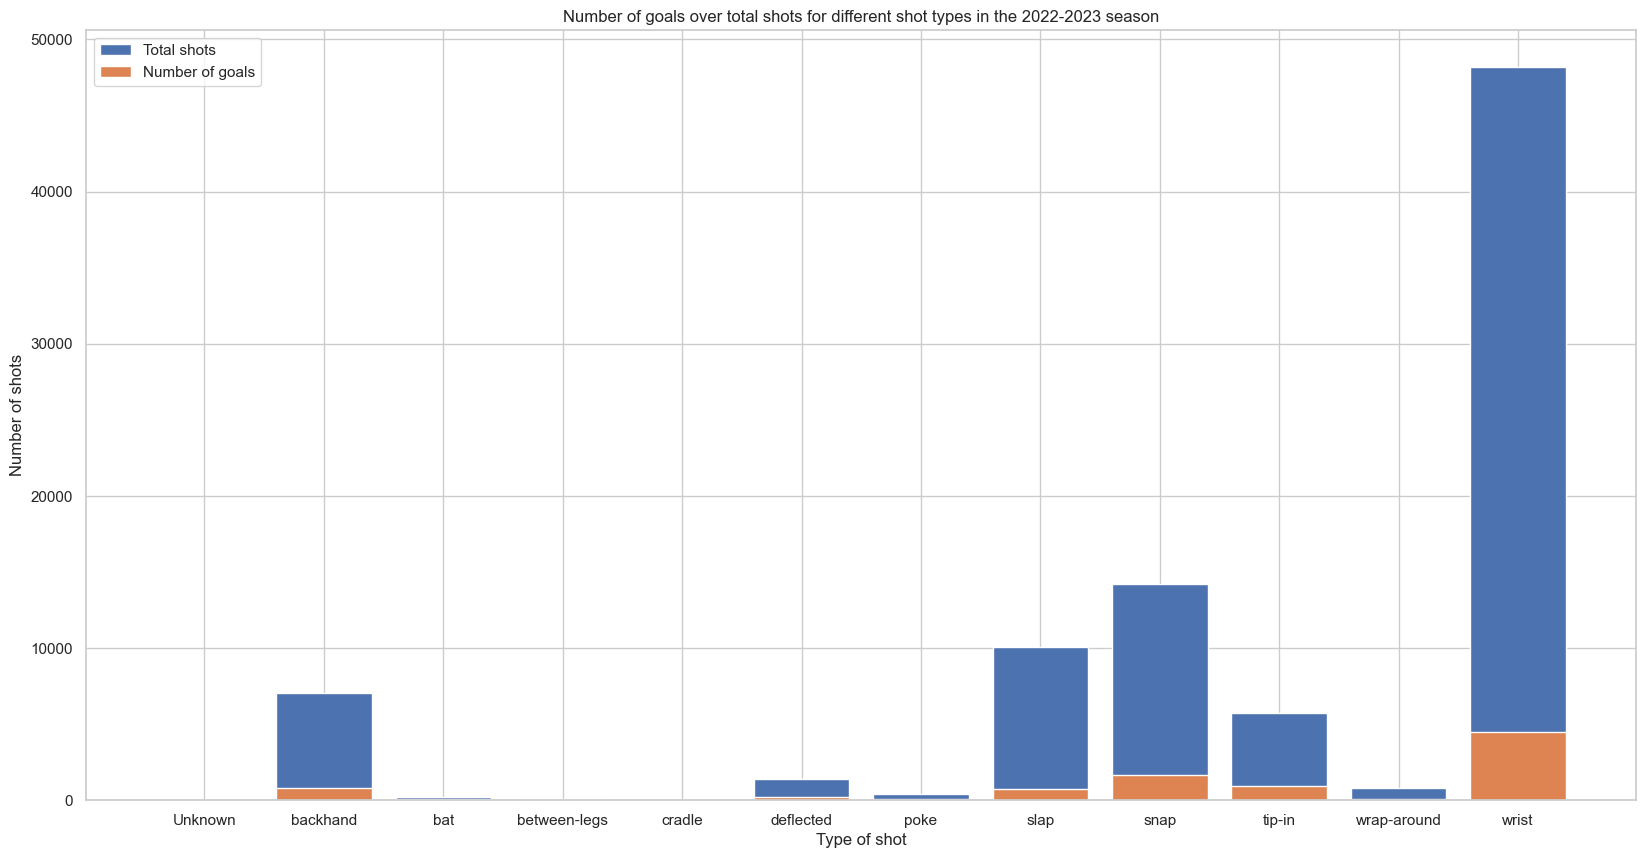

In [9]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(20,10))

plt.bar(shots_df.index, shots_df["total_shots"], label="Total shots")
plt.bar(shots_df.index, shots_df["goals"], label="Number of goals")

plt.xlabel("Type of shot")
plt.ylabel("Number of shots")
plt.title("Number of goals over total shots for different shot types in the 2022-2023 season")
#plt.yscale("log")
plt.legend()
plt.plot()

In [ ]:
########### a ###########

In [13]:
# First, we get the data from seasons 2018-2019, 2019-2020 and 2020-2021
season2018Data = SeasonData(2018)
season2018Data.get_data_from_api()
df_2018 = clean_season_data(season2018Data)

season2019Data = SeasonData(2019)
season2019Data.get_data_from_api()
df_2019 = clean_season_data(season2019Data)

season2020Data = SeasonData(2020)
season2020Data.get_data_from_api()
df_2020 = clean_season_data(season2020Data)

dfArray = [df_2018, df_2019, df_2020]

In [14]:
# Now, we compute the distance to the goal for every shot

# Since the coordinates were normalized in the cleaning step, the team will always shoot to the right goal, which is at coordinates x = 89, y = 0
goal_pos = np.array([89.0, 0.0])

for df in dfArray:
    shot_coords = df.apply(lambda x: np.array([x["standardized_x_coord"], x["standardized_y_coord"]]), axis=1)

    # Compute the euclidean distance between the position of the shot and the position of the goal for each shot
    distance_to_goal = shot_coords.apply(lambda x: np.linalg.norm(x - goal_pos))

    df["distance_from_goal"] = distance_to_goal.apply(lambda x: int(round(x)) if not pd.isna(x) else np.nan)

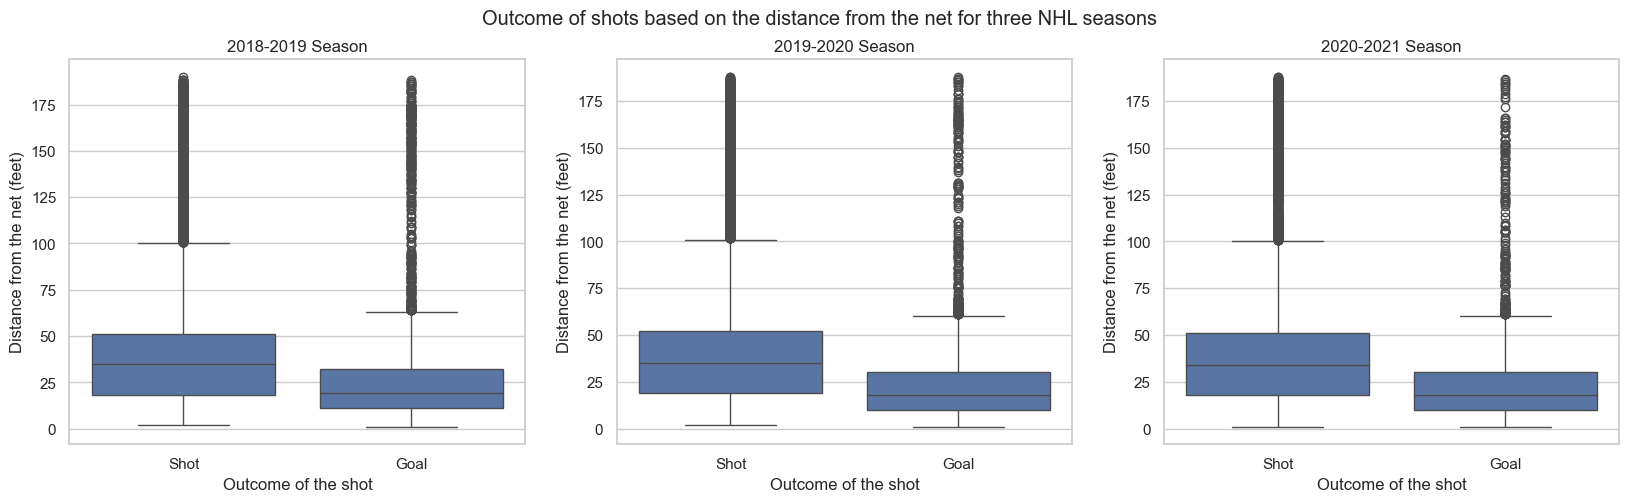

In [15]:
# Now, we plot the points for each of the seasons according to the distance to the goal
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Plotting the 2018-2019 season
sns.boxplot(x="event_type", y="distance_from_goal", data=df_2018, ax=ax[0])
ax[0].set_title("2018-2019 Season")
ax[0].set_xlabel("Outcome of the shot")
ax[0].set_ylabel("Distance from the net (feet)")

# Plotting the 2019-2020 season
sns.boxplot(x="event_type", y="distance_from_goal", data=df_2019, ax=ax[1])
ax[1].set_title("2019-2020 Season")
ax[1].set_xlabel("Outcome of the shot")
ax[1].set_ylabel("Distance from the net (feet)")
ax[1].invert_xaxis()

# Plotting the 2020-2021 season
sns.boxplot(x="event_type", y="distance_from_goal", data=df_2020, ax=ax[2])
ax[2].set_title("2020-2021 Season")
ax[2].set_xlabel("Outcome of the shot")
ax[2].set_ylabel("Distance from the net (feet)")

fig.suptitle("Outcome of shots based on the distance from the net for three NHL seasons")

plt.show()

In [ ]:
############################## Question 4 #2 ##############################

In [16]:
# We will consider the 2019-2020 season for this question

total_shots_df_2019 = df_2019.groupby(["shot_type", "distance_from_goal"])["event_type"].count()
goals_df_2019 = df_2019[df_2019["event_type"] == "Goal"].groupby(["shot_type", "distance_from_goal"])["event_type"].count()

total_shots_df_2019 = total_shots_df_2019.rename("total_shots")
goals_df_2019 = goals_df_2019.rename("goals")

shots_and_goals_df_2019 = pd.concat([total_shots_df_2019, goals_df_2019], axis=1).fillna(0)
shots_and_goals_df_2019["goals"] = shots_and_goals_df_2019["goals"].apply(lambda x: int(x) if not pd.isna(x) else np.nan)

shots_and_goals_df_2019["goals_percentage"] = (shots_and_goals_df_2019["goals"]/shots_and_goals_df_2019["total_shots"]) * 100
shots_and_goals_df_2019 = shots_and_goals_df_2019.reset_index()
print(shots_and_goals_df_2019)

    shot_type  distance_from_goal  total_shots  goals  goals_percentage
0     Unknown                 9.0            1      1        100.000000
1     Unknown                19.0            1      0          0.000000
2     Unknown                20.0            1      1        100.000000
3     Unknown                28.0            1      1        100.000000
4     Unknown                35.0            2      2        100.000000
..        ...                 ...          ...    ...               ...
964     wrist               184.0           16      1          6.250000
965     wrist               185.0           23      3         13.043478
966     wrist               186.0           13      1          7.692308
967     wrist               187.0           10      3         30.000000
968     wrist               188.0            2      1         50.000000

[969 rows x 5 columns]


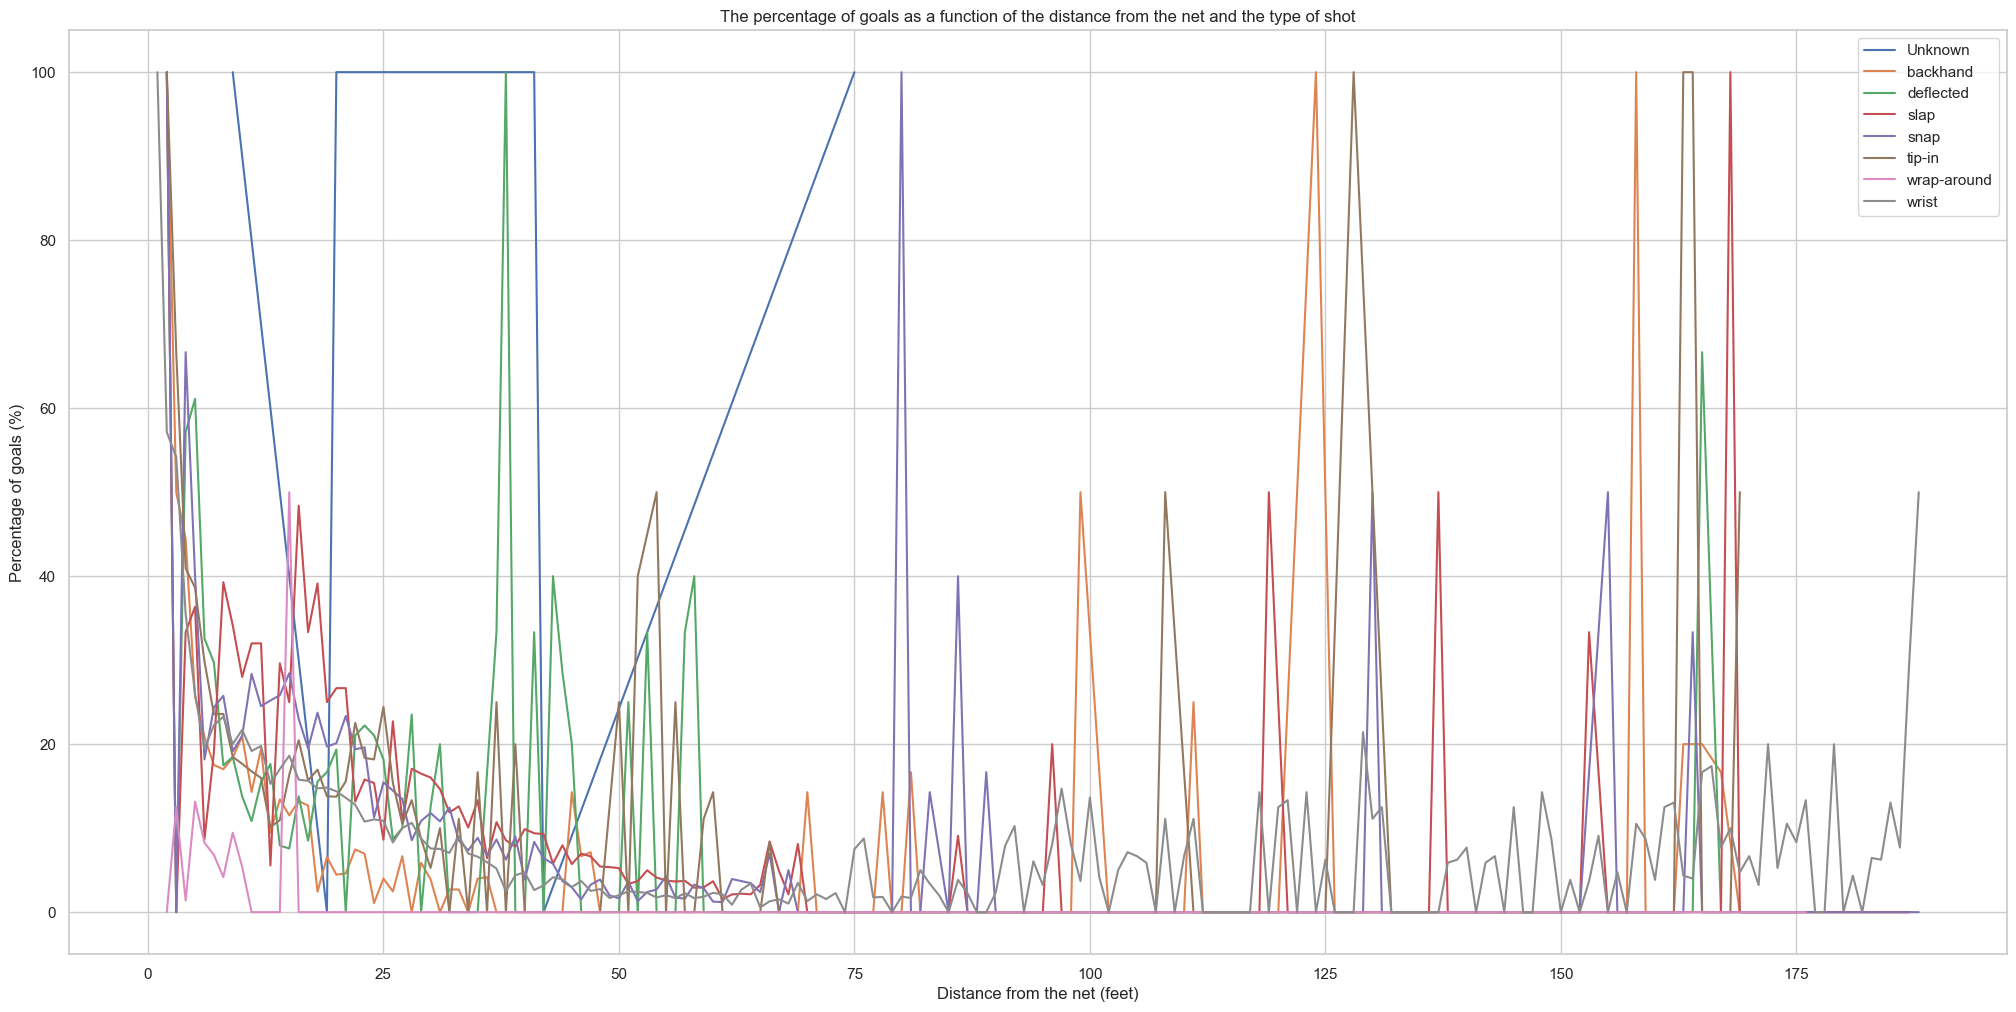

In [ ]:
# Now we plot

plt.figure(figsize=(25, 12))

for shot_type in shots_and_goals_df_2019["shot_type"].unique():
    distances = shots_and_goals_df_2019[shots_and_goals_df_2019["shot_type"] == shot_type]["distance_from_goal"]
    goals_perc = shots_and_goals_df_2019[shots_and_goals_df_2019["shot_type"] == shot_type]["goals_percentage"]

    plt.plot(distances, goals_perc, label=shot_type)

plt.title("The percentage of goals as a function of the distance from the net and the type of shot for the 2019-2020 season")
plt.xlabel("Distance from the net (feet)")
plt.ylabel("Percentage of goals (%)")
plt.legend()
plt.show()

In [18]:
# The graph is very messy, so we can try to smooth it out 

# First, let's round all the distances to their closest multiple of 10
shots_and_goals_df_2019["distance_from_goal"] = shots_and_goals_df_2019["distance_from_goal"].apply(lambda x: round(x/10) * 10 if not pd.isna(x) else np.nan)

# Now, we compute the mean for each multiple of 10 for each type of shot
smoothed_shots_and_goals_df_2019 = shots_and_goals_df_2019.groupby(["shot_type", "distance_from_goal"])["goals_percentage"].mean().reset_index()


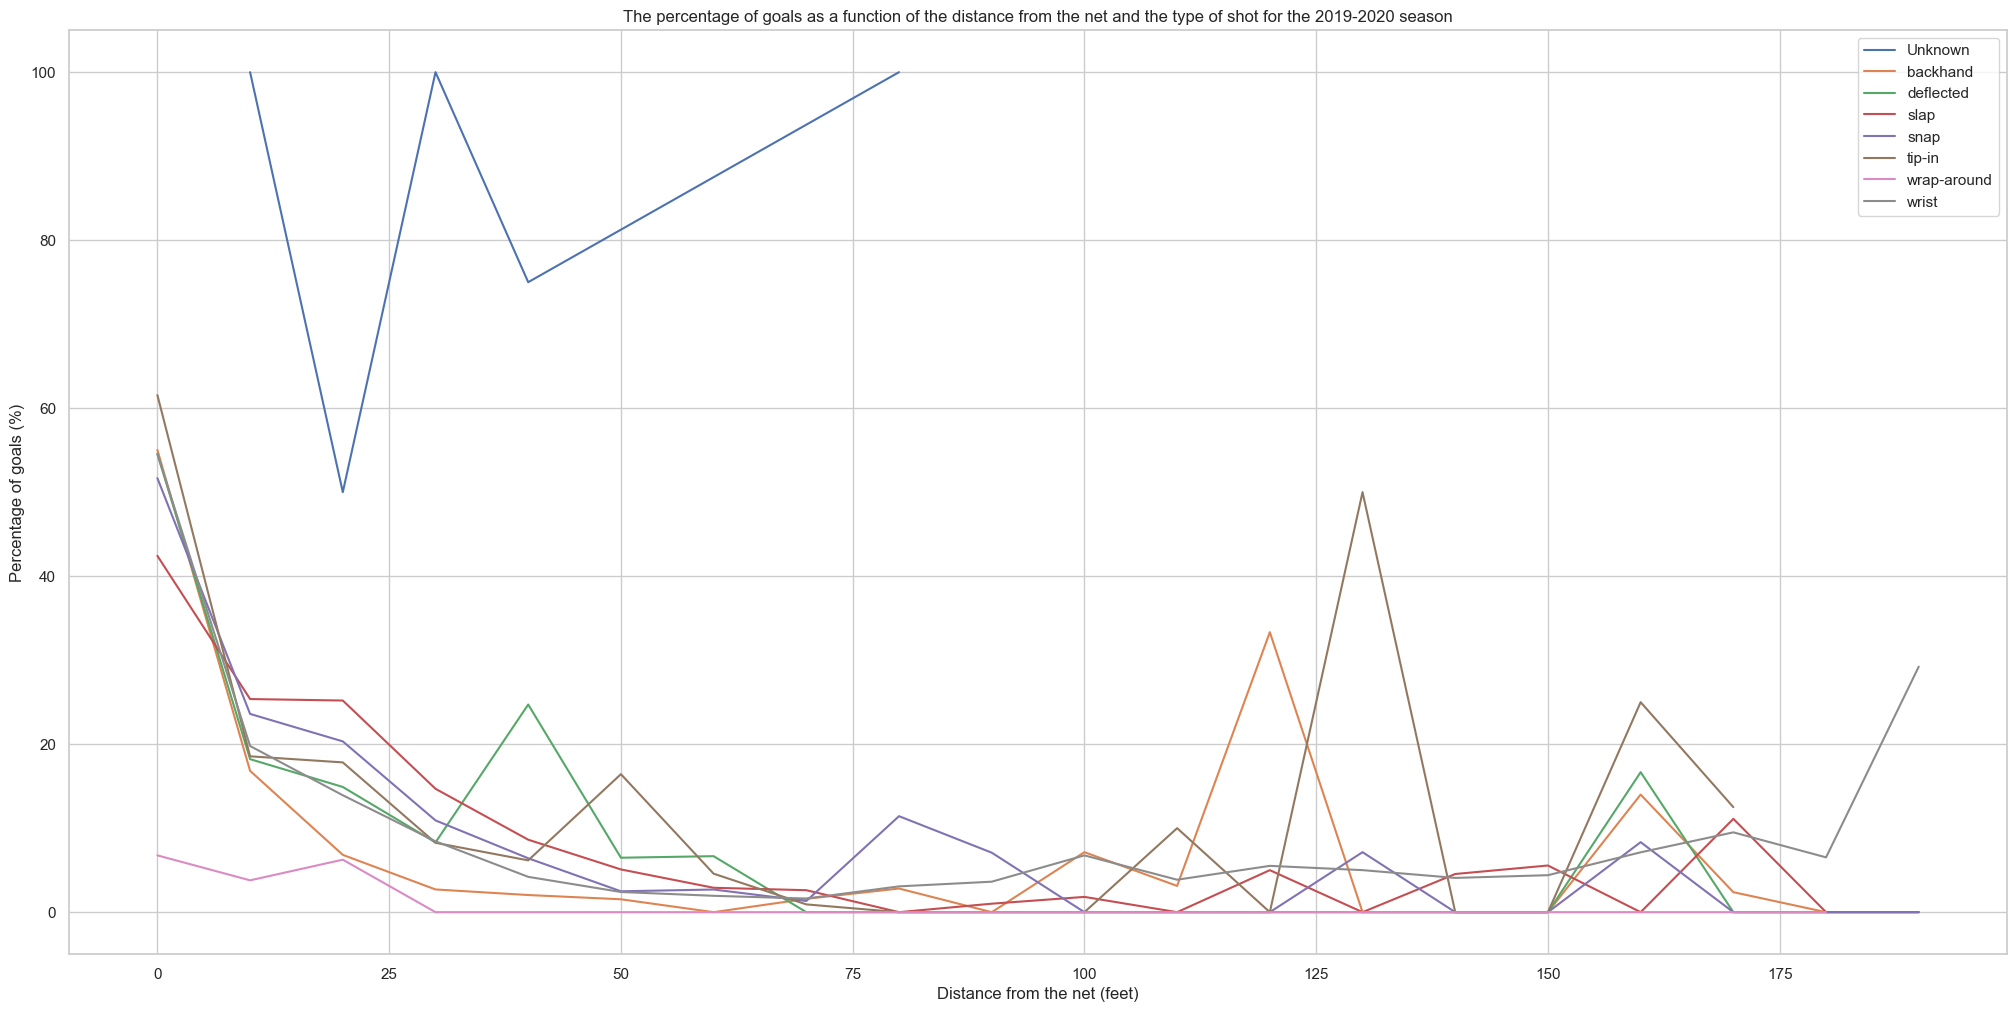

In [19]:
# Let's try and plot again
plt.figure(figsize=(25, 12))

for shot_type in smoothed_shots_and_goals_df_2019["shot_type"].unique():
    distances = smoothed_shots_and_goals_df_2019[smoothed_shots_and_goals_df_2019["shot_type"] == shot_type]["distance_from_goal"]
    goals_perc = smoothed_shots_and_goals_df_2019[smoothed_shots_and_goals_df_2019["shot_type"] == shot_type]["goals_percentage"]

    plt.plot(distances, goals_perc, label=shot_type)

plt.title("The percentage of goals as a function of the distance from the net and the type of shot for the 2019-2020 season")
plt.xlabel("Distance from the net (feet)")
plt.ylabel("Percentage of goals (%)")
plt.legend()
plt.show()